# G64 Overlapping Corner Blending Analysis

This notebook visualizes and analyzes what happens when G64 path blending is applied to
segments that are so short that the blend regions of adjacent corners overlap.

## Key Concepts

- **Blend Radius**: For G64 P tolerance, the inscribed blend arc has radius `r = P * cos(θ/2) / (1 - cos(θ/2))`
- **Tangent Distance**: Distance from corner to blend entry/exit: `d = r * tan(θ/2)`
- **Overlap occurs when**: `2 * tangent_distance > segment_length`

When corners overlap, the G64 blender must handle this gracefully, either by:
1. Reducing blend radii to fit
2. Skipping blending for segments that are too short
3. Merging adjacent blend arcs

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc, Circle, FancyArrowPatch
from matplotlib.collections import LineCollection
import matplotlib.colors as mcolors
from ipywidgets import interact, FloatSlider, IntSlider
%matplotlib inline

plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 10

## Blend Geometry Calculations

In [2]:
def compute_blend_geometry(tolerance, corner_angle_deg):
    """
    Compute blend arc geometry for a given tolerance and corner angle.
    
    Args:
        tolerance: Path tolerance (P value in G64)
        corner_angle_deg: Angle between direction vectors in degrees
        
    Returns:
        dict with radius, tangent_dist, half_angle
    """
    half_angle = np.deg2rad(corner_angle_deg / 2.0)
    cos_half = np.cos(half_angle)
    
    if abs(1.0 - cos_half) < 1e-10:
        return {'radius': float('inf'), 'tangent_dist': float('inf'), 'half_angle': half_angle}
    
    radius = tolerance * cos_half / (1.0 - cos_half)
    tangent_dist = radius * np.tan(half_angle)
    
    return {
        'radius': radius,
        'tangent_dist': tangent_dist,
        'half_angle': half_angle,
        'arc_sweep_deg': corner_angle_deg
    }


def create_zigzag_path(leg_length, turn_angle, num_corners):
    """
    Create a zig-zag path with specified leg length and turn angle.
    
    Returns:
        list of (x, y) corner points
    """
    points = [(0.0, 0.0)]
    current_dir = 0.0  # Degrees
    x, y = 0.0, 0.0
    
    for i in range(num_corners + 1):
        x += leg_length * np.cos(np.deg2rad(current_dir))
        y += leg_length * np.sin(np.deg2rad(current_dir))
        points.append((x, y))
        
        # Alternate turn direction
        if i % 2 == 0:
            current_dir += turn_angle
        else:
            current_dir -= turn_angle
    
    return points


def compute_direction(p1, p2):
    """Compute unit direction vector from p1 to p2."""
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    length = np.sqrt(dx*dx + dy*dy)
    if length < 1e-10:
        return (1.0, 0.0)
    return (dx / length, dy / length)


def compute_corner_angle(dir_in, dir_out):
    """Compute angle between two direction vectors in degrees."""
    dot = dir_in[0] * dir_out[0] + dir_in[1] * dir_out[1]
    dot = max(-1.0, min(1.0, dot))  # Clamp for numerical stability
    return np.rad2deg(np.arccos(dot))

## Visualize Blend Overlap

In [3]:
def plot_overlapping_blends(leg_length=5.0, turn_angle=60.0, tolerance=1.0, num_corners=4):
    """
    Visualize a zig-zag path with G64 blend arcs, showing overlap regions.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # Create path
    points = create_zigzag_path(leg_length, turn_angle, num_corners)
    
    # Compute blend geometry
    blend = compute_blend_geometry(tolerance, turn_angle)
    
    # Check for overlap
    tangent_needed = 2 * blend['tangent_dist']
    overlap_ratio = tangent_needed / leg_length
    is_overlapping = overlap_ratio > 1.0
    
    # Left plot: Full path view
    ax1.set_title(f"Zig-Zag Path with G64 P{tolerance}\n"
                  f"Leg: {leg_length}mm, Turn: {turn_angle}°, "
                  f"{'OVERLAPPING' if is_overlapping else 'No Overlap'}")
    
    # Draw original path (sharp corners)
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    ax1.plot(xs, ys, 'b--', alpha=0.3, linewidth=1, label='Sharp corners')
    
    # Draw blend arcs at each corner
    colors = plt.cm.Set1(np.linspace(0, 1, num_corners))
    
    for i in range(1, len(points) - 1):  # Skip first and last (no corners there)
        prev_pt = points[i-1]
        corner = points[i]
        next_pt = points[i+1]
        
        dir_in = compute_direction(prev_pt, corner)
        dir_out = compute_direction(corner, next_pt)
        corner_deg = compute_corner_angle(dir_in, dir_out)
        
        blend_i = compute_blend_geometry(tolerance, corner_deg)
        r = blend_i['radius']
        td = blend_i['tangent_dist']
        
        # Entry and exit points
        entry = (corner[0] - dir_in[0] * td, corner[1] - dir_in[1] * td)
        exit_pt = (corner[0] + dir_out[0] * td, corner[1] + dir_out[1] * td)
        
        # Check turn direction (CCW = left turn)
        cross = dir_in[0] * dir_out[1] - dir_in[1] * dir_out[0]
        is_ccw = cross > 0
        
        # Center perpendicular from entry
        if is_ccw:  # Left turn
            perp = (-dir_in[1], dir_in[0])
        else:  # Right turn
            perp = (dir_in[1], -dir_in[0])
        
        center = (entry[0] + perp[0] * r, entry[1] + perp[1] * r)
        
        # Draw blend arc
        start_angle = np.rad2deg(np.arctan2(entry[1] - center[1], entry[0] - center[0]))
        sweep = corner_deg if is_ccw else -corner_deg
        
        # Draw the arc
        angles = np.linspace(0, sweep, 50)
        arc_xs = [center[0] + r * np.cos(np.deg2rad(start_angle + a)) for a in angles]
        arc_ys = [center[1] + r * np.sin(np.deg2rad(start_angle + a)) for a in angles]
        ax1.plot(arc_xs, arc_ys, color=colors[i-1], linewidth=2, alpha=0.8)
        
        # Mark entry and exit
        ax1.plot(*entry, 'o', color=colors[i-1], markersize=6)
        ax1.plot(*exit_pt, 's', color=colors[i-1], markersize=6)
        
        # Draw center
        ax1.plot(*center, 'x', color=colors[i-1], markersize=8)
        
        # Draw radius circle (faint)
        circle = plt.Circle(center, r, fill=False, color=colors[i-1], linestyle=':', alpha=0.3)
        ax1.add_patch(circle)
        
        # Highlight overlap regions
        if is_overlapping:
            ax1.axvspan(entry[0] - 0.1, exit_pt[0] + 0.1, alpha=0.1, color=colors[i-1])
    
    # Draw corner points
    ax1.plot(xs[1:-1], ys[1:-1], 'ro', markersize=8, label='Corners')
    
    ax1.set_aspect('equal')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    ax1.set_xlabel('X (mm)')
    ax1.set_ylabel('Y (mm)')
    
    # Right plot: Overlap analysis
    ax2.set_title('Blend Overlap Analysis')
    
    # Bar chart: segment length vs required tangent distance
    segment_lengths = [leg_length] * num_corners
    required_spaces = [tangent_needed] * num_corners
    
    x_pos = np.arange(num_corners)
    width = 0.35
    
    bars1 = ax2.bar(x_pos - width/2, segment_lengths, width, label='Segment Length', color='blue', alpha=0.7)
    bars2 = ax2.bar(x_pos + width/2, required_spaces, width, label='2x Tangent Dist', color='red', alpha=0.7)
    
    # Add overlap indicator line
    ax2.axhline(y=leg_length, color='green', linestyle='--', label='Segment Limit')
    
    ax2.set_xlabel('Corner Index')
    ax2.set_ylabel('Distance (mm)')
    ax2.set_xticks(x_pos)
    ax2.legend()
    
    # Add metrics text
    metrics = f"""
    Blend Geometry:
    • Tolerance: {tolerance:.2f} mm
    • Corner angle: {turn_angle:.1f}°
    • Blend radius: {blend['radius']:.3f} mm
    • Tangent dist: {blend['tangent_dist']:.3f} mm
    • Required space: {tangent_needed:.3f} mm
    • Segment length: {leg_length:.2f} mm
    • Overlap ratio: {overlap_ratio:.1%}
    • Status: {'⚠️ OVERLAPPING' if is_overlapping else '✅ OK'}
    """
    ax2.text(0.98, 0.98, metrics, transform=ax2.transAxes, fontsize=9,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             family='monospace')
    
    plt.tight_layout()
    plt.show()
    
    return blend, overlap_ratio

## Interactive Visualization

Use the sliders to explore how changing segment length, turn angle, and tolerance
affects blend overlap.

In [4]:
interact(
    plot_overlapping_blends,
    leg_length=FloatSlider(value=5.0, min=0.5, max=20.0, step=0.5, description='Leg Length (mm)'),
    turn_angle=FloatSlider(value=60.0, min=10.0, max=150.0, step=5.0, description='Turn Angle (°)'),
    tolerance=FloatSlider(value=1.0, min=0.1, max=5.0, step=0.1, description='Tolerance (mm)'),
    num_corners=IntSlider(value=4, min=2, max=8, step=1, description='Num Corners')
)

interactive(children=(FloatSlider(value=5.0, description='Leg Length (mm)', max=20.0, min=0.5, step=0.5), Floa…

<function __main__.plot_overlapping_blends(leg_length=5.0, turn_angle=60.0, tolerance=1.0, num_corners=4)>

## Overlap Threshold Analysis

Find the critical tolerance at which overlap begins for a given segment length and angle.

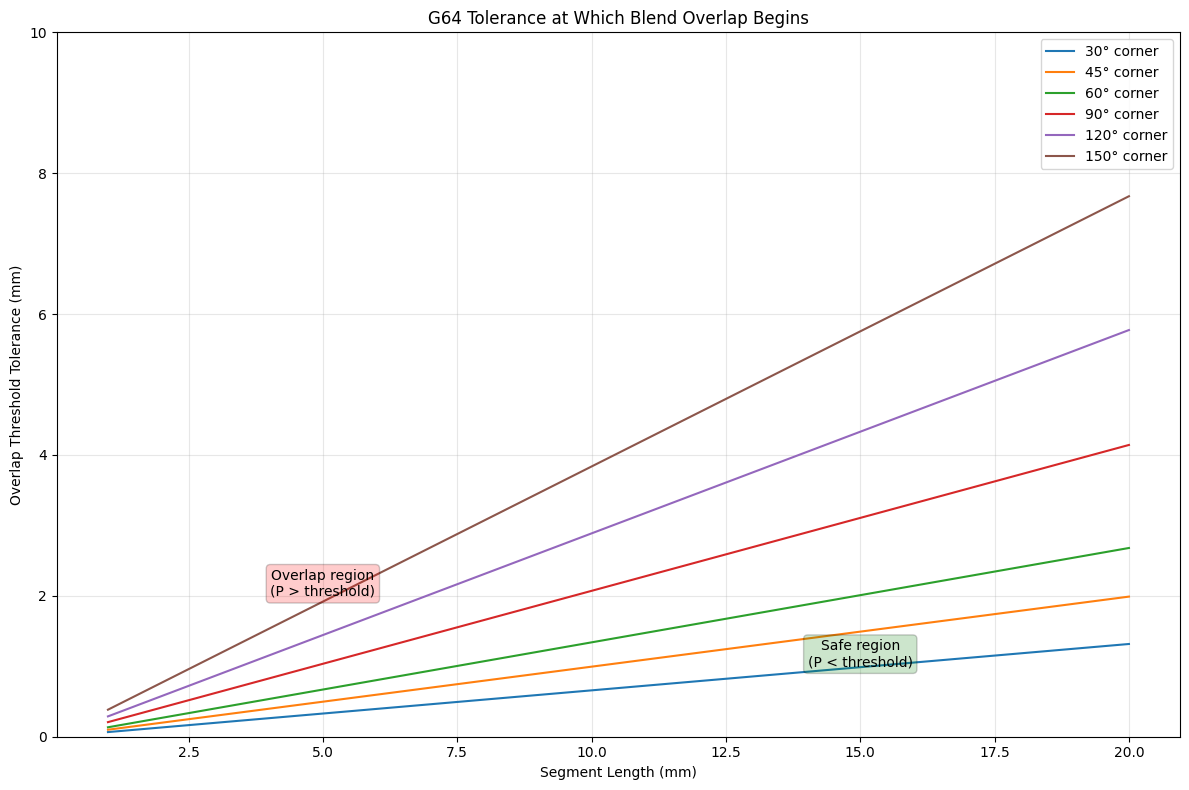

In [5]:
def find_overlap_threshold(leg_length, corner_angle):
    """
    Find the tolerance at which blend regions start to overlap.
    """
    half_angle = np.deg2rad(corner_angle / 2.0)
    tan_half = np.tan(half_angle)
    cos_half = np.cos(half_angle)
    
    # Overlap occurs when 2 * r * tan(θ/2) > leg_length
    # r = P * cos(θ/2) / (1 - cos(θ/2))
    # So: 2 * P * cos(θ/2) * tan(θ/2) / (1 - cos(θ/2)) > leg_length
    # P > leg_length * (1 - cos(θ/2)) / (2 * cos(θ/2) * tan(θ/2))
    # P > leg_length * (1 - cos(θ/2)) / (2 * sin(θ/2))
    
    sin_half = np.sin(half_angle)
    if sin_half < 1e-10:
        return float('inf')
    
    threshold = leg_length * (1.0 - cos_half) / (2.0 * sin_half)
    return threshold


# Plot threshold curves for different angles
fig, ax = plt.subplots(figsize=(12, 8))

leg_lengths = np.linspace(1, 20, 100)
angles = [30, 45, 60, 90, 120, 150]

for angle in angles:
    thresholds = [find_overlap_threshold(L, angle) for L in leg_lengths]
    ax.plot(leg_lengths, thresholds, label=f'{angle}° corner')

ax.set_xlabel('Segment Length (mm)')
ax.set_ylabel('Overlap Threshold Tolerance (mm)')
ax.set_title('G64 Tolerance at Which Blend Overlap Begins')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 10)

# Add annotation
ax.annotate('Overlap region\n(P > threshold)', 
            xy=(5, 2), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='red', alpha=0.2))
ax.annotate('Safe region\n(P < threshold)', 
            xy=(15, 1), fontsize=10, ha='center',
            bbox=dict(boxstyle='round', facecolor='green', alpha=0.2))

plt.tight_layout()
plt.show()

## How G64PathBlender Handles Overlap

When blend regions would overlap, the G64PathBlender handles this by:

1. **Segment too short**: If the segment length is less than 2x the tangent distance,
   the blender reduces the blend radius to fit, or skips blending entirely.

2. **Adjacent blends merge**: In extreme cases, adjacent blend arcs might effectively
   merge into a single smooth curve.

3. **Path remains connected**: Regardless of overlap, the output path must always
   be connected (no gaps between segments).

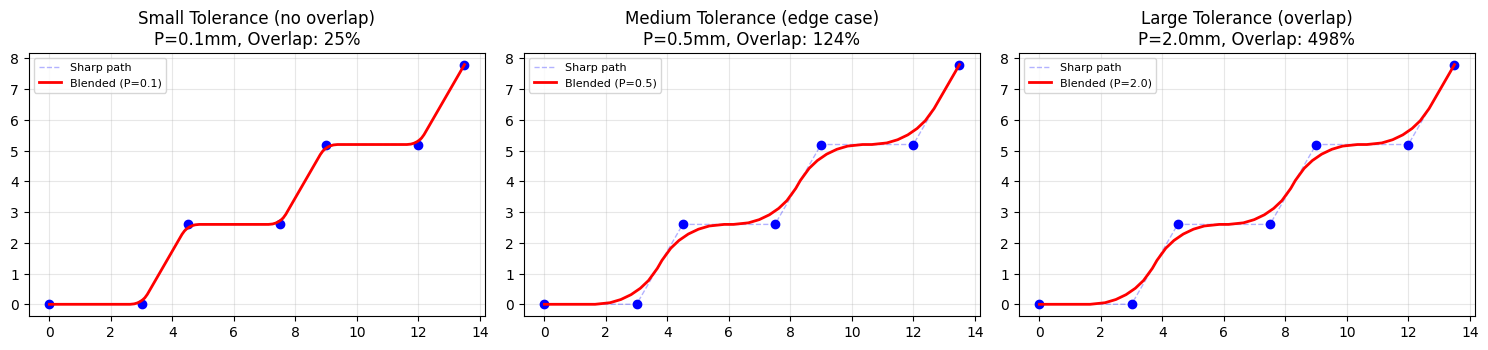

In [6]:
def simulate_blended_path(points, tolerance):
    """
    Simulate G64 blending with overlap handling.
    Returns list of (x, y) points representing the blended path.
    """
    if len(points) < 3:
        return points
    
    blended = [points[0]]
    
    for i in range(1, len(points) - 1):
        prev_pt = points[i-1]
        corner = points[i]
        next_pt = points[i+1]
        
        # Segment lengths
        seg1_len = np.sqrt((corner[0]-prev_pt[0])**2 + (corner[1]-prev_pt[1])**2)
        seg2_len = np.sqrt((next_pt[0]-corner[0])**2 + (next_pt[1]-corner[1])**2)
        min_seg = min(seg1_len, seg2_len)
        
        dir_in = compute_direction(prev_pt, corner)
        dir_out = compute_direction(corner, next_pt)
        corner_deg = compute_corner_angle(dir_in, dir_out)
        
        if corner_deg < 5.0 or corner_deg > 175.0:
            # Near-straight or near-reversal - skip blending
            blended.append(corner)
            continue
        
        blend = compute_blend_geometry(tolerance, corner_deg)
        
        # Check if blend fits
        if blend['tangent_dist'] * 2 > min_seg * 0.9:
            # Reduce blend to fit (use 45% of segment length as tangent distance)
            td = min_seg * 0.45
            r = td / np.tan(blend['half_angle'])
        else:
            td = blend['tangent_dist']
            r = blend['radius']
        
        # Compute blend arc
        entry = (corner[0] - dir_in[0] * td, corner[1] - dir_in[1] * td)
        exit_pt = (corner[0] + dir_out[0] * td, corner[1] + dir_out[1] * td)
        
        cross = dir_in[0] * dir_out[1] - dir_in[1] * dir_out[0]
        is_ccw = cross > 0
        
        if is_ccw:
            perp = (-dir_in[1], dir_in[0])
        else:
            perp = (dir_in[1], -dir_in[0])
        
        center = (entry[0] + perp[0] * r, entry[1] + perp[1] * r)
        
        # Generate arc points
        start_angle = np.arctan2(entry[1] - center[1], entry[0] - center[0])
        sweep = np.deg2rad(corner_deg) if is_ccw else -np.deg2rad(corner_deg)
        
        blended.append(entry)
        for t in np.linspace(0.2, 0.8, 5):
            angle = start_angle + t * sweep
            blended.append((center[0] + r * np.cos(angle), center[1] + r * np.sin(angle)))
        blended.append(exit_pt)
    
    blended.append(points[-1])
    return blended


# Compare blending with and without overlap handling
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

leg_length = 3.0
turn_angle = 60.0
points = create_zigzag_path(leg_length, turn_angle, 5)

tolerances = [0.1, 0.5, 2.0]
titles = ['Small Tolerance (no overlap)', 'Medium Tolerance (edge case)', 'Large Tolerance (overlap)']

for ax, tol, title in zip(axes, tolerances, titles):
    # Original path
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    ax.plot(xs, ys, 'b--', alpha=0.3, linewidth=1, label='Sharp path')
    ax.plot(xs, ys, 'bo', markersize=6)
    
    # Blended path
    blended = simulate_blended_path(points, tol)
    bxs = [p[0] for p in blended]
    bys = [p[1] for p in blended]
    ax.plot(bxs, bys, 'r-', linewidth=2, label=f'Blended (P={tol})')
    
    blend = compute_blend_geometry(tol, turn_angle)
    overlap_ratio = (2 * blend['tangent_dist']) / leg_length
    
    ax.set_title(f'{title}\nP={tol}mm, Overlap: {overlap_ratio:.0%}')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Summary

### Key Takeaways

1. **Blend overlap is geometry-dependent**: Larger tolerances and sharper angles create larger blend radii,
   which require more space on each segment.

2. **Overlap threshold formula**: `P_threshold = L * (1 - cos(θ/2)) / (2 * sin(θ/2))`
   where L is segment length and θ is turn angle.

3. **Handling strategies**:
   - Reduce blend radius to fit available space
   - Skip blending for very short segments
   - Always maintain path connectivity

4. **Testing**: The `OverlappingCornerBlendTest` suite validates these behaviors with
   various segment lengths, angles, and tolerance values.